In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
import joblib
df = pd.read_csv('data/4020177.csv')
df.head

<bound method NDFrame.head of            STATION                      NAME        DATE  PRCP  SNOW  SNWD  \
0      USC00198368  NWS BOSTON NORTON, MA US    7/1/1994  0.00   0.0   NaN   
1      USC00198368  NWS BOSTON NORTON, MA US    7/2/1994  0.00   0.0   NaN   
2      USC00198368  NWS BOSTON NORTON, MA US    7/3/1994  0.00   0.0   NaN   
3      USC00198368  NWS BOSTON NORTON, MA US    7/4/1994  0.00   0.0   NaN   
4      USC00198368  NWS BOSTON NORTON, MA US    7/5/1994  0.00   0.0   NaN   
...            ...                       ...         ...   ...   ...   ...   
10357  USC00198368  NWS BOSTON NORTON, MA US  11/10/2022  0.00   0.0   0.0   
10358  USC00198368  NWS BOSTON NORTON, MA US  11/11/2022  0.00   0.0   0.0   
10359  USC00198368  NWS BOSTON NORTON, MA US  11/12/2022  0.54   0.0   0.0   
10360  USC00198368  NWS BOSTON NORTON, MA US  11/13/2022  0.12   0.0   0.0   
10361  USC00198368  NWS BOSTON NORTON, MA US  11/14/2022  0.19   0.0   0.0   

       TMAX  TMIN  TOBS  WESD  WE

In [2]:
core_weather = df[["PRCP","TMAX","TMIN"]].copy()
core_weather.columns = ["Rain","Temp_max","Temp_min"]

In [3]:
core_weather

,Rain,Temp_max,Temp_min
0,0.00,83.0,64.0
1,0.00,84.0,58.0
2,0.00,83.0,64.0
3,0.00,84.0,62.0
4,0.00,82.0,53.0
...,...,...,...
10357,0.00,53.0,32.0
10358,0.00,69.0,43.0
10359,0.54,71.0,51.0
10360,0.12,73.0,51.0


In [4]:
bins = list(range(60, 105, 5))
labels = list(range(1, len(bins)))

# Create binned column
core_weather["Temp_max_range"] = pd.cut(core_weather["Temp_max"], bins=bins, labels=labels, right=False)

# Optional: fill NaN with 0 or another value if outside range
core_weather["Temp_max_range"] = core_weather["Temp_max_range"].fillna(3)
core_weather["Temp_max_range"]

0        5
1        5
2        5
3        5
4        5
        ..
10357    3
10358    2
10359    3
10360    3
10361    3
Name: Temp_max_range, Length: 10362, dtype: category
Categories (8, int64): [1 < 2 < 3 < 4 < 5 < 6 < 7 < 8]

In [10]:
bins = list(range(0, 80, 5))
labels = list(range(1, len(bins)))

# Create binned column
core_weather["Temp_min_range"] = pd.cut(core_weather["Temp_min"], bins=bins, labels=labels, right=False)

# Optional: fill NaN with 0 or another value if outside range
core_weather["Temp_min_range"] = core_weather["Temp_min_range"].fillna(1)
core_weather["Temp_min_range"]

C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\894474308.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  core_weather["Temp_min_range"] = pd.cut(core_weather["Temp_min"], bins=bins, labels=labels, right=False)
C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\894474308.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  core_weather["Temp_min_range"] = core_weather["Temp_min_range"].fillna(1)


0        13
1        12
2        13
3        13
4        11
         ..
10356     7
10357     7
10358     9
10359    11
10360    11
Name: Temp_min_range, Length: 10361, dtype: category
Categories (15, int64): [1 < 2 < 3 < 4 ... 12 < 13 < 14 < 15]

In [14]:
bins = np.arange(0, 3.05, 0.05)
labels = list(range(1, len(bins)))

# Create binned column
core_weather["Rain_range"] = pd.cut(core_weather["Rain"], bins=bins, labels=labels, right=False)

# Optional: fill NaN with 0 or another value if outside range
core_weather["Rain_range"] = core_weather["Rain_range"].fillna(1)
core_weather["Rain_range"]

C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\2877037499.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  core_weather["Rain_range"] = pd.cut(core_weather["Rain"], bins=bins, labels=labels, right=False)
C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\2877037499.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  core_weather["Rain_range"] = core_weather["Rain_range"].fillna(1)


0         1
1         1
2         1
3         1
4         1
         ..
10356     1
10357     1
10358     1
10359    11
10360     3
Name: Rain_range, Length: 10361, dtype: category
Categories (60, int64): [1 < 2 < 3 < 4 ... 57 < 58 < 59 < 60]

In [15]:
core_weather["target"] = core_weather["Temp_max_range"].shift(-1)

# Drop rows with NaN in target
core_weather = core_weather.dropna(subset=["target"])

# Define predictors and target
predictors = ["Temp_max_range", "Temp_min_range", "Rain_range"]  # or add more features
target = "target"


C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\1254157733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  core_weather["target"] = core_weather["Temp_max_range"].shift(-1)


In [20]:
train = core_weather.loc[:10340]   # rows 0 to 9000
test = core_weather.loc[10341:]    # rows from 9000 onwards

# Train the Ridge regression model
reg = Ridge(alpha=0.1)
reg.fit(train[predictors], train[target])

# Predict on test set
predictions = reg.predict(test[predictors])

# Add predictions to test set for comparison
test["predicted_range"] = predictions

# Optionally: round predictions to nearest bin label
test["predicted_range_rounded"] = test["predicted_range"]

C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\1431953357.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["predicted_range"] = predictions
C:\Users\mckays1\AppData\Local\Temp\ipykernel_14204\1431953357.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["predicted_range_rounded"] = test["predicted_range"]


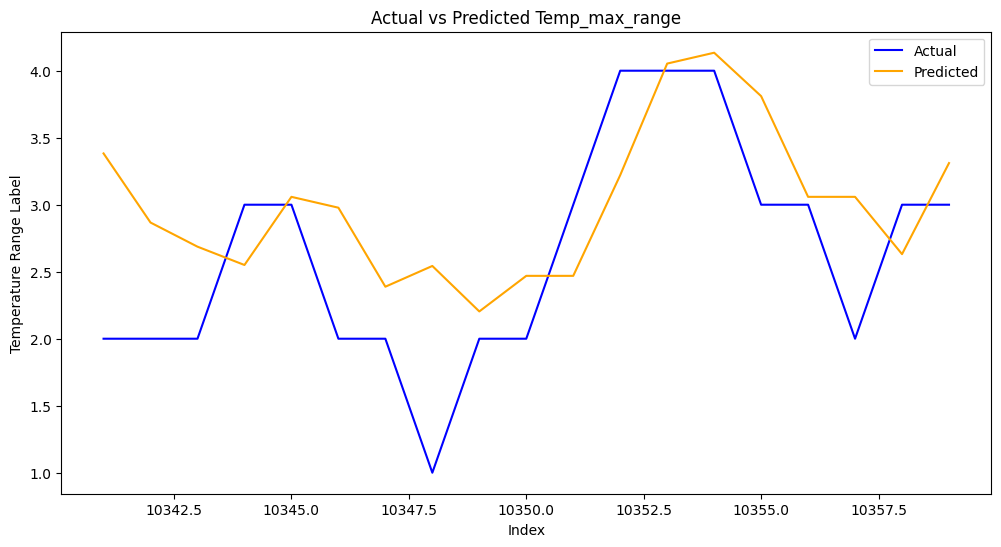

In [22]:
plt.figure(figsize=(12, 6))

# Plot actual Temp_max_range
plt.plot(test.index, test["target"], label="Actual", color="blue")

# Plot predicted Temp_max_range (rounded)
plt.plot(test.index, test["predicted_range_rounded"], label="Predicted", color="orange")

plt.title("Actual vs Predicted Temp_max_range")
plt.xlabel("Index")
plt.ylabel("Temperature Range Label")
plt.legend()
plt.tight_layout()
plt.show()